In [ ]:
!pip install google-generativeai pandas matplotlib scikit-learn streamlit

In [ ]:
import sqlite3
import pandas as pd
import google.generativeai as genai
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [ ]:
conn = sqlite3.connect("factory.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE inventory(
item_id INTEGER PRIMARY KEY,
name TEXT,
sku TEXT,
stock_level INTEGER,
reorder_point INTEGER
)
""")

cursor.execute("""
CREATE TABLE production_line(
entry_id INTEGER PRIMARY KEY,
model_id TEXT,
shift TEXT,
units_produced INTEGER,
timestamp TEXT
)
""")

cursor.execute("""
CREATE TABLE shipping(
order_id INTEGER PRIMARY KEY,
destination TEXT,
quantity INTEGER,
status TEXT
)
""")

In [ ]:
inventory_data = [
(1,"85-inch UHD Panel","TV85UHD",120,200),
(2,"65-inch QLED Panel","TV65QLED",350,300),
(3,"55-inch Crystal Panel","TV55CRY",500,250),
(4,"Mainboard Assembly","MB-889",700,400),
(5,"Speaker Module","SP-55",900,500)
]

cursor.executemany("INSERT INTO inventory VALUES (?,?,?,?,?)", inventory_data)


production_data = [
(1,"TV85UHD","A",450,"2026-03-10 08:00"),
(2,"TV85UHD","B",500,"2026-03-10 16:00"),
(3,"TV65QLED","A",600,"2026-03-10 08:00"),
(4,"TV65QLED","B",650,"2026-03-10 16:00")
]

cursor.executemany("INSERT INTO production_line VALUES (?,?,?,?,?)", production_data)


shipping_data = [
(1,"Kathmandu",200,"Shipped"),
(2,"Pokhara",150,"Processing"),
(3,"Biratnagar",100,"Pending")
]

cursor.executemany("INSERT INTO shipping VALUES (?,?,?,?)", shipping_data)

conn.commit()

In [ ]:
#Gemini configuration
import google.generativeai as genai
from google.colab import userdata
genai.configure(api_key=userdata.get("GOOGLE_API_KEY"))
model = genai.GenerativeModel("gemini-2.5-flash")

In [ ]:
def get_schema():

    tables = pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type='table';",
        conn
    )

    schema = ""

    for table in tables['name']:

        columns = pd.read_sql_query(
            f"PRAGMA table_info({table});",
            conn
        )

        col_names = columns['name'].tolist()

        schema += f"{table}({', '.join(col_names)})\n"

    return schema

In [ ]:
conversation_history = []
def generate_sql(question):

    schema = get_schema()

    history_text = "\n".join(conversation_history[-4:])

    prompt = f"""
You are an SQL assistant for a manufacturing ERP system.

Database Schema:
{schema}

Conversation context:
{history_text}

Rules:
- Only generate SELECT queries
- Never generate DELETE, UPDATE, INSERT, DROP
- Return SQL only

User question:
{question}
"""

    response = model.generate_content(prompt)

    sql = response.text.strip()

    # Remove markdown code block if present
    if sql.startswith("```sql") and sql.endswith("```"):
        sql = sql[len("```sql\n"):-len("```")].strip()

    conversation_history.append(question)

    return sql

Now the assistant remembers the last few questions.

#### Automatic Explanation Generator

In [ ]:
def explain_results(question, df):

    prompt = f"""
A factory manager asked this question:

{question}

Here is the data returned:

{df.to_string()}

Explain the insight in simple business language.
Focus on operational risks like inventory shortage or production delays.
"""

    response = model.generate_content(prompt)

    return response.text

#### Inventory Shortage Prediction (Simple ML)

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

def predict_inventory_shortage():

    df = pd.read_sql_query(
        "SELECT stock_level, reorder_point FROM inventory",
        conn
    )

    X = np.arange(len(df)).reshape(-1,1)
    y = df["stock_level"]

    model = LinearRegression()
    model.fit(X,y)

    future = model.predict([[len(df)+3]])

    return future[0]

We can predict when inventory will fall below reorder level.

#### Full Ask Function

In [ ]:
def validate_query(query):

    forbidden = ["DELETE","DROP","UPDATE","INSERT","ALTER"]

    for word in forbidden:
        if word in query.upper():
            raise Exception("Unsafe SQL detected")

    return True

In [ ]:
query_cache = {}

def cached_query(sql):

    if sql in query_cache:
        print("Using cached result")
        return query_cache[sql]

    df = pd.read_sql_query(sql, conn)

    query_cache[sql] = df

    return df

In [ ]:
def ask_factory(question):

    sql = generate_sql(question)

    print("Generated SQL:")
    print(sql)

    validate_query(sql)

    df = cached_query(sql)

    explanation = explain_results(question, df)

    return df, explanation

#### Test the Copilot

In [ ]:
df, explanation = ask_factory(
    "Show inventory items where stock is below reorder point"
)

df

Generated SQL:
SELECT
  item_id,
  name,
  sku,
  stock_level,
  reorder_point
FROM
  inventory
WHERE
  stock_level < reorder_point;


,item_id,name,sku,stock_level,reorder_point
0,1,85-inch UHD Panel,TV85UHD,120,200


In [ ]:
print(explanation)

Here's the insight explained in simple business language, focusing on operational risks:

---

**Insight: Critical Shortage Alert for 85-inch UHD Panels**

This data shows a major red flag: Our stock of **85-inch UHD Panels (SKU: TV85UHD)** is **below its critical reorder point.**

*   We currently have **120 units** on hand.
*   Our established safety threshold (reorder point) is **200 units**.

This means we have already passed the point where we should have placed a new order to replenish stock. We are now running on reserves that are thinner than intended.

**Operational Risks:**

1.  **Imminent Inventory Shortage:** We are rapidly approaching a complete stock-out of a critical component. If an order isn't placed and received soon, we will literally run out.

2.  **Production Stoppage & Delays:**
    *   If the 85-inch UHD Panel is a key component for our 85-inch TVs (or other products), we face a **high risk of production delays or even a complete shutdown** of that particular pro

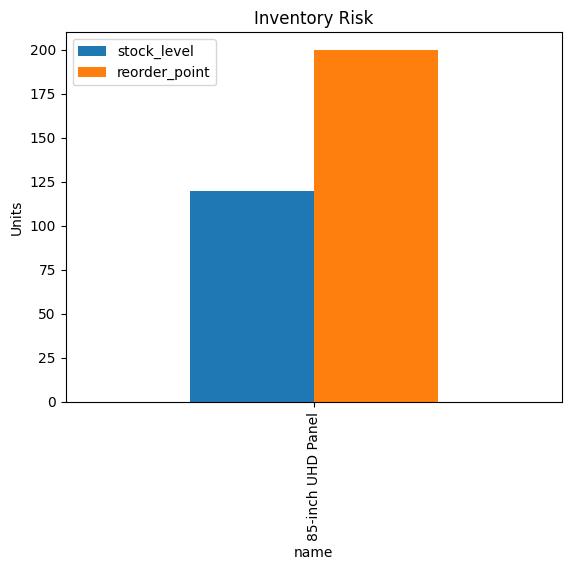

In [ ]:
df.set_index("name")[["stock_level","reorder_point"]].plot(kind="bar")

plt.title("Inventory Risk")
plt.ylabel("Units")
plt.show()

In [ ]:
df1, explanation1 = ask_factory(
    "How many TVs were produced in shift A?"
)

df1

Generated SQL:
SELECT SUM(pl.units_produced)
FROM production_line AS pl
JOIN inventory AS i
  ON pl.model_id = i.item_id
WHERE
  i.name = 'TV' AND pl.shift = 'A';


,SUM(pl.units_produced)
0,None


In [ ]:
print(explanation1)

This "None" result is a critical red flag, far more concerning than a "0".

**Insight in Simple Business Language:**

"None" means we have **absolutely no record or information** about how many TVs were produced in Shift A. It doesn't mean zero were produced; it means the system couldn't find any relevant data to sum up.

**Operational Risks:**

1.  **Inventory Shortage & Inaccurate Stock:**
    *   **Impact:** If we don't know what Shift A produced, our physical inventory counts are immediately unreliable. We could promise customers TVs we don't have, leading to missed shipments, cancelled orders, and damaged customer trust.
    *   **Risk:** We won't know if we have enough product in the warehouse to fulfill current orders, or to prepare for future demand. This directly leads to potential stock-outs and a inability to meet sales targets.

2.  **Production Delays & Bottleneck Identification:**
    *   **Impact:** We can't track Shift A's output. Was there a machine breakdown? A materi